# Generate a SBAT4-like short GRB population

In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import pickle
import afterglowpy as grb

#from tqdm.notebook import tqdm
from scipy.integrate import quad, quad_vec, cumulative_trapezoid
from astropy.cosmology import Planck18 as cosmo

In [2]:
# constants and unit conversions
h = 6.62 * 1.0e-34      # Planck constant in J/Hz
c = 299792458.      # light speed in m/s
keV2J = 1e3 * 1.6e-19     # conversion keV to joules
erg2J = 1e-7        # conversion erg to joules

In [12]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

## Method to create a population of GRBs

To create a population of sGRBs based on the SBAT4 catalog, we use the following method. The goal of the calculations is to compute the on-axis flux that would be received by the Swift BAT instrument considering the GRB parameters and to apply the cut that was applied on the sGRBs composing the SBAT4 catalog ($PF_{64} > 3.5$ ph/s/cm²). 

**1.** The first step is to generate useful parameters. The parameters used to compute the flux are the following: 
- $E_{Core}$: the energy of the jet core in erg,
- $\theta_{Core}$: the jet width in radians,
- $\theta_{Obs}$: the observer angle in radians, < $\theta_{Core}$ because we are on-axis here,
- $z$ and $d_L$: redshift and corresponding luminosity distance, assuming a Planck18 cosmology ($H_0$ = 67.66 km/(Mpc.s), $\Omega_0$ = 0.30966),
- $T_{90}$: duration of a GRB (< 2 seconds for short GRBs),
- $\Gamma_{Core}$: bulk Lorentz factor of the jet in the core.

All these parameters are generated according to a uniform distribution, except the redshift which follows the following distribution:
$$ P(z) = \frac{\frac{dV_c}{dz} \frac{\dot \rho_{sGRBs}}{1+z}}{\int_0^\infty\frac{dV_c}{dz} \frac{\dot \rho_{sGRBs}}{1+z}dz} $$

**2.** The isotropic equivalent energy of the jet emitted at the observer angle is then computed thanks to a power-law angular energy structure:
$$ E(\theta_{Obs}) = E_{Core}\left(1 + \frac{1}{b}\left(\frac{\theta_{Obs}}{\theta_{Core}}\right)\right)^{b/2} $$
Where $b$ = 4 to have a quite "steep" structure. $E_{\gamma, iso}$ is then computed by taking a small portion of the total $E_{iso}$: $E_{\gamma, iso} = \eta_\gamma E_{iso} \approx 0.1 E_{iso}$ ($\eta_\gamma$ is called the prompt efficiency, but this is something to check more thoroughly).

The Lorentz factor at the observer angle is computed thanks to:
$$ \Gamma(\theta_{Obs}) = 1 + \frac{\Gamma_{Core} - 1}{1 + \left(\frac{\theta_{Obs}}{\theta_{Core}}\right)^a} $$
Where $a$ = 3.5. 

All of these variables are stored in a list of dictionaries.

**3.** We want to compute the flux that would be received by Swift BAT, in $photons/s/cm^2$:
$$ \frac{d \dot N}{dA} = \int_{15keV}^{150keV} \frac{F_\nu}{h\nu} d\nu $$

With $F_\nu = \frac{1+z}{4\pi d_L²} L_\nu = \frac{1+z}{4\pi d_L²} \left(\frac{hL}{E_p}\right) S(\nu')$, where:
- $E_p = \Gamma E_p'$ is the peak energy in the observer frame, $E_p'$ is the peak energy in the comoving frame and is set to 3 keV,
- $L = 2 \times \frac{E_{iso}}{T_{90}}$ is the average luminosity (factor 2 being here to correct the fact that we take into account the average luminosity and not the peak luminosity),
- $S(\nu') \propto \nu'^a \exp \left[(−(1 + a)\frac{\nu'}{\nu_p'}\right]$ is a cut-off power-law spectral shape, to cut the luminosity at high energies, with a spectral index a=0.3 (normalized).

**4.** The obtained flux $\frac{d \dot N}{dA}$ is called $F_{BAT}$ and is compared to the SBAT4 $PF_{64}$, which is the peak photon flux computed using the 15–150 keV Swift-BAT light curves binned with $\delta t$ = 64 ms. To select only the GRBs that look like the SBAT4 catalog, we apply on our simulated GRBs fluxes the same cut that was applied to the SBAT4 GRBs ($F_{BAT} > 3.5$ photons/s/cm²).

## Defining some useful functions...

In [147]:
def generate_grb_population(nb_grbs):
    """ Function to generate a population of GRBs
    """
    
    grb_population = []

    # generate randomly some parameters
    ECore = np.random.uniform(47, 54, nb_grbs)    # in erg
    thetaCore = np.random.uniform(0.01, 0.3, nb_grbs)   # in radians
    thetaWing = np.random.uniform(0.01, np.pi/2, nb_grbs)   # in radians
    thetaObs = np.arccos(np.random.uniform(0., 1., nb_grbs))   # in radians
    n = 10 ** (-np.random.uniform(-2, 2, nb_grbs))   # in cm-3
    z = np.random.choice(z_list, nb_grbs)
    dL = cosmo.luminosity_distance(z).value * 3.08e22   # in m
    T90 = np.random.uniform(0.01, 2., nb_grbs)  # T90 in seconds
    
    # calculate the Lorentz factor
    GammaCore = 10 ** np.random.uniform(2., 3., nb_grbs)
    Gamma = lorentz_factor(GammaCore, thetaObs, thetaCore)
    
    E = 10**ECore * (1 + (1/4) * (thetaObs/thetaCore)**2)**(-4/2) # power-law angular structure of the energy
    eta_gamma = 0.1
    Eiso = E * eta_gamma   # conversion of the energy to gamma radiation energy
    
    # tore the parameters of the simulated GRB
    grb = {'Eiso': Eiso,
           'E0': 10**ECore,
           'thetaCore': thetaCore,
           'thetaObs': thetaObs,
           'thetaWing': thetaWing,
           'n': n,
           'z': z,
           'dL': dL,
           'Gamma': Gamma,
           'T90': T90
           }
    
    Fbat = calculate_bat_flux(grb)
    grb['Fbat'] = Fbat

    return grb


def calculate_flux(nu, grb):
    """Function to calculate the spectral luminosity of the GRB at the viewing angle
    """
    
    Eiso = grb['Eiso'] * erg2J    # energy in Joule
    thetaCore = grb['thetaCore']
    thetaObs = grb['thetaObs']
    z = grb['z']
    dL = grb['dL']
    Gamma = grb['Gamma']
    T90 = grb['T90']
    
    Ep_comoving = 3. * keV2J    # energy of the peak in the rest-frame in J
    nup_prime = Ep_comoving / h    # convert the energy of the peak in a frequency
    a = 0.3   # spectral index (typical)

    Ep = Gamma * Ep_comoving
    L = 2 * Eiso / T90   # in J/s
    nu_prime = nu / (1+z)
    
    # cut-off power law comoving spectral shape
    # numerical integration to normalize the flux
    nu_values = np.linspace(15*keV2J/h, 150*keV2J/h, 1000)    # BAT frequency range
    norm = np.trapz(spectral_shape(nu_values, nup_prime, a))
    # normalized spectral shape
    normalized_S = spectral_shape(nu_prime, nup_prime, a) / norm
    
    Lnu = (h * L / Ep) * normalized_S

    Fnu = (1+z) / (4*np.pi*dL**2) * Lnu
    
    # convert the flux in a flux of photons
    Fphot = Fnu / (h*nu)

    return Fphot


def spectral_shape(nu_prime, nup_prime, a):
    """Function to calculate the cut-off power law comoving spectral shape (has to be normalized): 
    S(ν') ∝ ν'^3.5 * exp(−(1 + 3.5)ν'/νp')
    (arXiv:1905.01190v2)
    """
    
    S = nu_prime**a * np.exp(-(1+a) * (nu_prime/nup_prime))
    
    return S


def lorentz_factor(GammaCore, thetaObs, thetaCore):
    """Function to calculate the Lorentz factor: 
    Γ(θ) = 1 + (Γc − 1) / (1 + (θ/θc))^3.5
    (arXiv:1905.01190v2)
    """
    
    Gamma = 1 + (GammaCore - 1) / (1 + (thetaObs/thetaCore)**3.5)

    return Gamma
    
    
def calculate_bat_flux(grb):
    """Calculate the flux of the GRB received by Swift BAT
    """
        
    nu_min = 15. * keV2J / h   # min frequency of BAT in Hz
    nu_max = 150. * keV2J / h   # max frequency of BAT in Hz
    Fbat, err = quad_vec(calculate_flux, nu_min, nu_max, args=grb)

    return Fbat * 1e-4   # in photons/s/cm2

### Test

In [191]:
# SBAT4 catalog data
# list of GRBs from D'Avanzo et al. 2014
catalog = {'grb_name': ['051221A', '070714B', '080123', '080905A', '090426', '090510', '090515', '100117A', 
                        '100625A', '101219A', '111117A', '130603B'],
           'z': [0.547, 0.92, 0.495, 0.122, 2.609, 0.903, 0.403, 0.92, 0.452, 0.718, 1.3, 0.356],
           'T90': [1.4, 80.0, 115.18, 1.02, 1.24, 0.3, 0.04, 0.3, 0.33, 0.6, 0.47, 0.18],   # in seconds
           'flux': [40.7, 8.1, 6.1, 3.7, 4.7, 20.1, 5.2, 4.4, 9.3, 8.9, 5.8, 54.2]}  # in photons/cm2/s


# generating a redshift distribution
z0 = np.linspace(0., 2.6, 1000)
pdf = cosmo.differential_comoving_volume(z0) / (1+z0)
pdf /= np.trapz(pdf, z0)
cdf = cumulative_trapezoid(pdf, z0, initial=0)
z_list = np.interp(np.random.uniform(0., 1., 1000), cdf, z0)
#print(z_list[z_list<0.1])  # ~ detection limit of LIGO-Virgo for BNS


# generate population of GRBs 
nb_grbs = 66230  # number of simulated GRBs

print(f'Generating {nb_grbs} GRBs...')
grb_population = generate_grb_population(nb_grbs)

print('Keeping GRBs with a flux > 3.5 ph/s/cm2...')
cut = 3.5    # cut applied to the SBAT4 catalog (PF64 > 3.5 ph/s/cm2)
cut_grbs = dict()
for k in grb_population.keys():
    cut_grbs[k] = grb_population[k][np.where(grb_population['Fbat'] > cut)]

print('Done!')
print(f"Number of GRBs left: {len(cut_grbs['E0'])}")

Generating 500 GRBs...
Keeping GRBs with a flux > 3.5 ph/s/cm2...
Done!
Number of GRBs left: 55


Text(0, 0.5, 'number of GRBs')

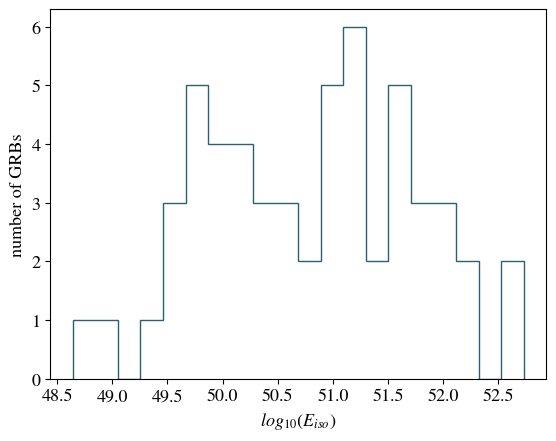

In [192]:
E0 = cut_grbs['Eiso']

plt.hist(np.log10(E0), bins=20, histtype='step', color='#296073');
plt.xlabel('$log_{10}(E_{iso})$')
plt.ylabel('number of GRBs')

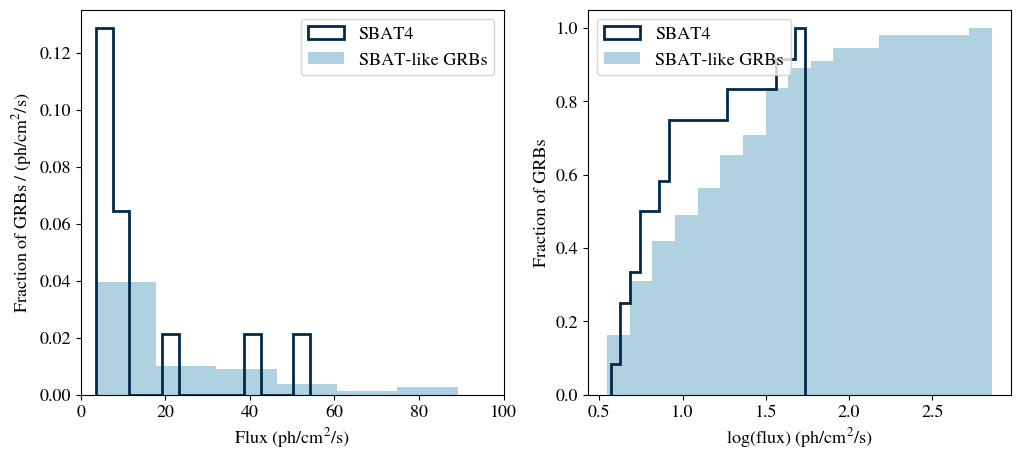

In [194]:
Fbat = cut_grbs['Fbat']
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(figsize=(12,5), nrows=1, ncols=2)

ax[0].hist(catalog['flux'], bins=13, density=True, histtype='step', linewidth=2, label='SBAT4', color='#012a4a')
ax[0].hist(Fbat, bins=50, density=True, alpha=0.5, linewidth=2, label='SBAT-like GRBs', color='#61a5c2');
ax[0].set_xlabel('Flux (ph/cm$^2$/s)')
ax[0].set_ylabel('Fraction of GRBs / (ph/cm$^2$/s)')
#ax[0].set_title('Distribution')
ax[0].set_xlim(-0.01, 100)
ax[0].legend()

ax[1].hist(np.log10(catalog['flux']), bins=20, histtype='step', linewidth=2, density=True, cumulative=True, label='SBAT4', color='#012a4a')
ax[1].hist(np.log10(Fbat), bins=17, density=True, cumulative=True, alpha=0.5, label='SBAT-like GRBs', color='#61a5c2');
ax[1].set_xlabel('log(flux) (ph/cm$^2$/s)')
ax[1].set_ylabel('Fraction of GRBs')
#ax[1].set_xlim(-0.01, 200)
#ax[1].set_xscale('log')
#ax[1].set_title('Cumulative');
ax[1].legend()

#plt.savefig('../figures/comparison_sbat4_grb_pop.pdf', format="pdf", bbox_inches="tight", transparent=True)

## Generating a population of GRBs consistent with the SBAT4 catalog

In [148]:
nb_grbs = 1000
nb_cut_grbs = 1000

cut = 3.5 

grb_pop = {'Eiso': np.array([]),
           'E0': np.array([]),
           'thetaCore': np.array([]),
           'thetaObs': np.array([]),
           'thetaWing': np.array([]),
           'n': np.array([]),
           'z': np.array([]),
           'dL': np.array([]),
           'Gamma': np.array([]),
           'T90': np.array([]),
           'Fbat': np.array([])
           }

cut_grbs.update(grb_pop)

print(f"Generating at least {nb_cut_grbs} GRBs with a flux > {cut} ph/s/cm²...")

# simulating a certain amount of short GRBs
while len(cut_grbs['z']) < nb_cut_grbs:

    # generating a redshift distribution
    z0 = np.linspace(0., 2.6, 1000)
    pdf = cosmo.differential_comoving_volume(z0) / (1+z0)
    pdf /= np.trapz(pdf, z0)
    cdf = cumulative_trapezoid(pdf, z0, initial=0)
    z_list = np.interp(np.random.uniform(0., 1., 1000), cdf, z0)
    
    grbs = generate_grb_population(nb_grbs)

    for k in grbs.keys():
        
        key = np.append(grb_pop[k], grbs[k])
        grb_pop[k] = key
        
        cut_key = np.append(cut_grbs[k], grbs[k][np.where(grbs['Fbat'] > cut)])
        cut_grbs[k] = cut_key
        
print('Done!')
print(f"Generated {len(cut_grbs['E0'])} GRBs with a flux > {cut} ph/s/cm².")

Generating at least 1000 GRBs with a flux > 3.5 ph/s/cm²...
Done!
Generated 1067 GRBs with a flux > 3.5 ph/s/cm².


<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_436880/292499037.py:18: SyntaxWarning: invalid escape sequence '\l'
  labels = ['$\log_{10}(E_{iso})$', r'$\theta_c$ (rad)', '$z$', r'$\theta_{obs}$ (rad)']


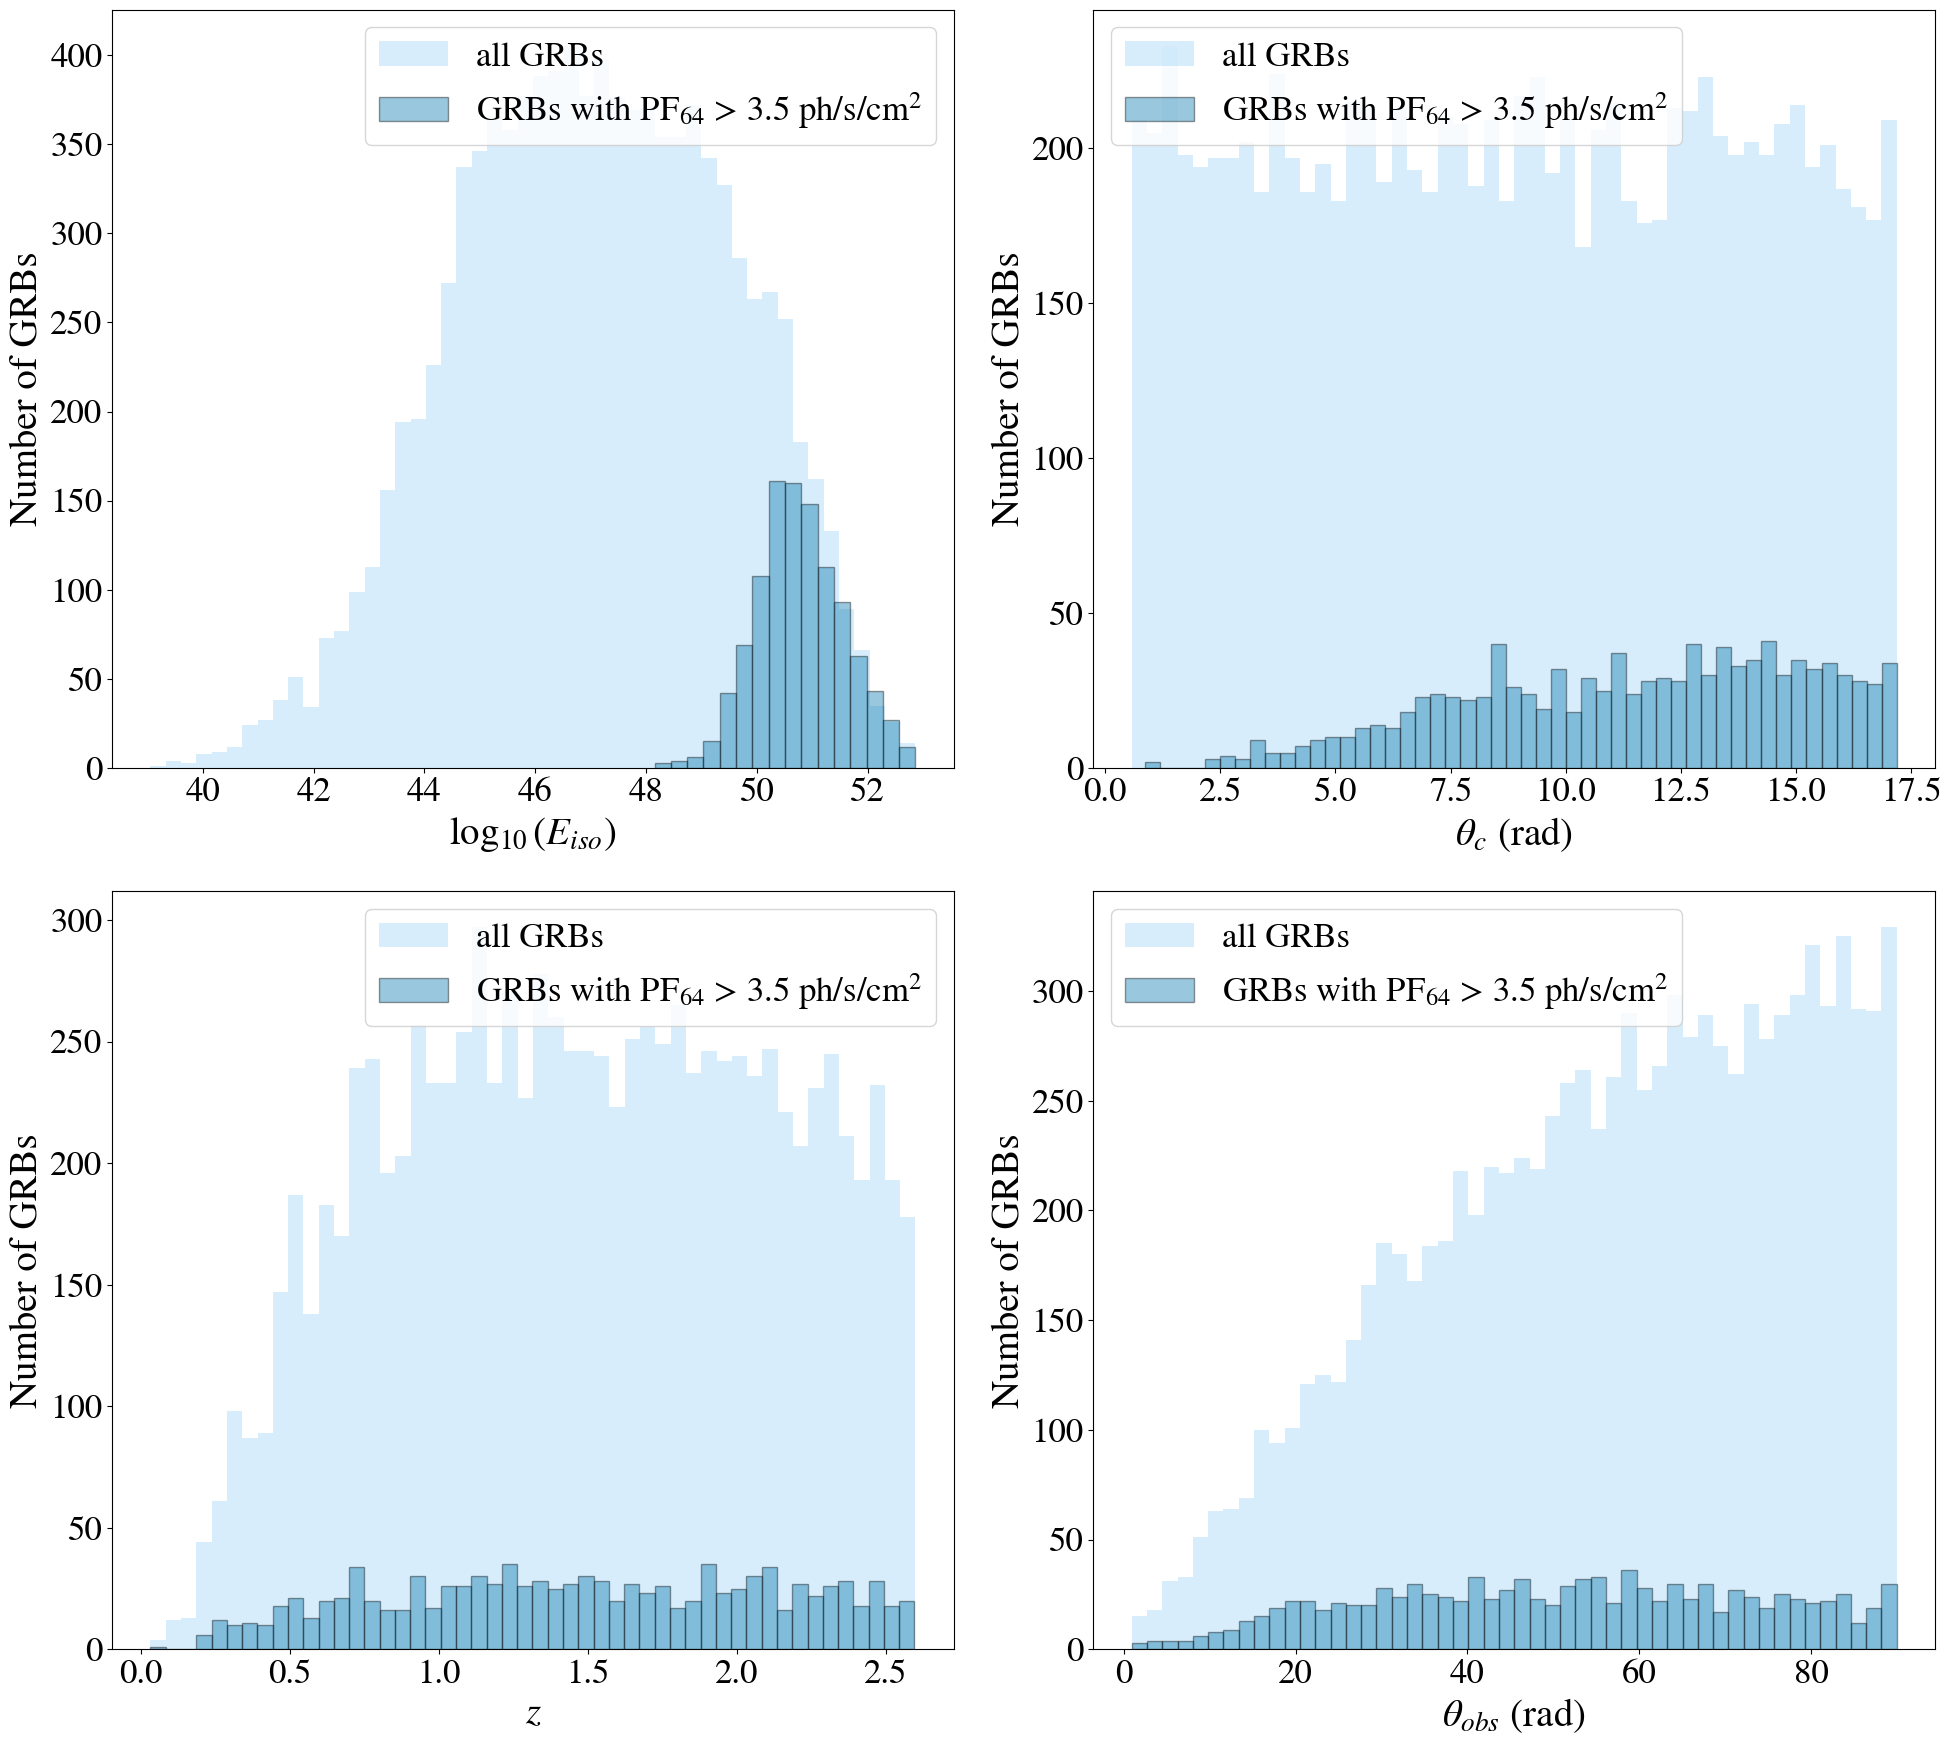

In [151]:
# all generated parameters distributions
E0_all = np.array(grb_pop['Eiso'])
thetaCore_all = np.array(grb_pop['thetaCore'])
Gamma_all = np.array(grb_pop['Gamma'])
z_all = np.array(grb_pop['z'])
thetaObs_all = np.array(grb_pop['thetaObs'])

# parameters distributions for consistent GRBs
E0_cut = np.array(cut_grbs['Eiso'])
thetaCore_cut = np.array(cut_grbs['thetaCore'])
Gamma_cut = np.array(cut_grbs['Gamma'])
z_cut = np.array(cut_grbs['z'])
thetaObs_cut = np.array(cut_grbs['thetaObs'])


params_all = [np.log10(E0_all), np.degrees(thetaCore_all), z_all, np.degrees(thetaObs_all)]
params_cut = [np.log10(E0_cut), np.degrees(thetaCore_cut), z_cut, np.degrees(thetaObs_cut)]
labels = ['$\log_{10}(E_{iso})$', r'$\theta_c$ (rad)', '$z$', r'$\theta_{obs}$ (rad)']

plt.rcParams.update({'font.size': 25})
fig, axes = plt.subplots(figsize=(20,18), nrows=2, ncols=2)
axes = axes.flatten()

for i in range(4):
    ax = axes[i]
    ax.hist(params_all[i], bins=50, label='all GRBs', color='#7ec6f3', alpha=0.3)
    ax.hist(params_cut[i], bins=50 if i > 0 else 16, 
            label='GRBs with PF$_{64}$ > 3.5 ph/s/cm$^2$', 
            edgecolor='k', color='#0075ad', alpha=0.4)
    
    ax.set_xlabel(labels[i], fontsize=28)
    ax.set_ylabel('Number of GRBs', fontsize=28)
    ax.legend()

plt.tight_layout()
#plt.savefig('../figures/grb_sbat4_pop_distrib.pdf', format="pdf", bbox_inches="tight", transparent=True)
plt.show()

## Method to keep only the "orphan" GRBs

Now that we have a population of GRBs that is consistent with the SBAT4 catalogue, we want to keep only the GRBs that would have an orphan afterglow (ie an afterglow without a prompt emission). To do that, we compute the flux of the afterglow and keep only those that have a maximum flux below the detection limit of Fermi GBM in the 50-300 keV band.

For each configuration of ($E_0$, $\theta_{obs}$, $\theta_c$, $n_0$, $z$), we compute the afterglow spectral flux with `afterglowpy` in J/m²/s/Hz (knowing that 1 mJy = 10⁻²⁹ J/m²/s/Hz). We then keep only the maximum value. To compute the flux in ph/cm²/s, we use: $F_{photon} = F_\nu / (h\nu) \times 10^{-4}$, $h$ being the Planck constant.

To have the flux over the whole band, we integrate $F_{photon}$ between the 50 and 300 keV: $F = 10^{-4} \times \int_{50keV}^{300keV} \frac{F_\nu}{h\nu} d\nu$.

In [12]:
def X_flux(nu, tmax, params):
    """ Flux for an array of frequency but one value of t
    """
        
    grb_params = {'jetType':     grb.jet.PowerLaw,     # Top-Hat jet
                  'specType':    0,      # Basic Synchrotron Emission Spectrum
                  'b':           4,      # Power-Law index
                  'thetaObs':    params[0],    # Viewing angle in radians
                  'E0':          params[1], # Isotropic-equivalent energy in erg
                  'thetaCore':   params[2],    # Half-opening angle in radians
                  'thetaWing':   np.pi/2,   # Truncature angle
                  'n0':          params[3],    # circumburst density in cm^{-3}
                  'p':           2.2,    # electron energy distribution index
                  'epsilon_e':   0.1,    # epsilon_e
                  'epsilon_B':   0.01,   # epsilon_B
                  'xi_N':        1.0,    # Fraction of electrons accelerated
                  'd_L':         cosmo.luminosity_distance(params[4]).value * 3.08e24, # Luminosity distance in cm
                  'z':           params[4]}   # Redshift
    # print("call fluxDensity with n=", n)
    Fnu = grb.fluxDensity(tmax*grb.day2sec, nu, **grb_params) * 1e-29   # flux in J/m2/s/Hz
    Fphot = np.array(Fnu) / (h*nu)  # photon flux
    return Fphot


def time_flux_max(params, nu_X=100 * keV2J / h):
    """Compute and return the time of the max flux value in the X band
    """
    
    st = np.geomspace(1.0e-2, 100, 20)  # time in days

    grb_params = {'jetType':     grb.jet.PowerLaw,     # Top-Hat jet
                  'specType':    0,      # Basic Synchrotron Emission Spectrum
                  'b':           4,      # Power-Law index
                  'thetaObs':    params[0],    # Viewing angle in radians
                  'E0':          params[1], # Isotropic-equivalent energy in erg
                  'thetaCore':   params[2],    # Half-opening angle in radians
                  'thetaWing':   np.pi/2,   # Truncature angle
                  'n0':          params[3],    # circumburst density in cm^{-3}
                  'p':           2.2,    # electron energy distribution index
                  'epsilon_e':   0.1,    # epsilon_e
                  'epsilon_B':   0.01,   # epsilon_B
                  'xi_N':        1.0,    # Fraction of electrons accelerated
                  'd_L':         cosmo.luminosity_distance(params[4]).value * 3.08e24, # Luminosity distance in cm
                  'z':           params[4]}   # Redshift
    # print("call fluxDensity with n=", n)
    Fnu = grb.fluxDensity(st*grb.day2sec, nu_X, **grb_params) * 1e-29   # flux in J/m2/s/Hz
    # return the time of the max Flux value in the X band
    imax = np.argmax(Fnu)
    return st[imax]


def X_fluence_max(E0, thetaCore, thetaObs, n0, z):
    """Integrate flux on the whole frequency channel of the Fermi GBM instrument
    """
    
    params = [thetaObs, E0, thetaCore, n0, z]
    tFmax = time_flux_max(params)
    Fgbm, err = quad(X_flux, nu_min_gbm, nu_max_gbm, args=(tFmax, params))
    return Fgbm * 1e-4

In [13]:
nu_min_gbm = 50. * keV2J / h
nu_max_gbm = 300. * keV2J / h

Fgbm = []
# we only compute the flux for 100 GRBs as the process is a bit slow
for i in tqdm(range(100)):
    
    E0 = cut_grbs['E0'][i]
    thetaCore = cut_grbs['thetaCore'][i]
    thetaObs = cut_grbs['thetaObs'][i]
    n0 = cut_grbs['n'][i]
    z = cut_grbs['z'][i]

    fgbm = X_fluence_max(E0, thetaCore, thetaObs, n0, z)
    Fgbm.append(fgbm)   # in ph/cm2/s

  0%|          | 0/100 [00:00<?, ?it/s]

For all the GRBs with a GBM flux < 0.5 ph/cm²/s, we compute the flux in the r-band in AB Magnitude. Only the GRBs with an AB Magnitude < 24.5 (observable) will be kept.

### Plot the parameters distributions for SBAT4-like orphan afterglows

In [201]:
file_po_open = open(f'../data/orphans_pseudo_obs_5pts_low_redshift.pkl', 'rb')
po = pickle.load(file_po_open)
file_po_open.close()

In [206]:
n_pts = []
dt = []
for p in po:
    n_pts.append(len(np.array(p['mags'])[np.array(p['mags'])<np.array(p['mags_lim'])]))
    obs_time = np.array(p['time'])[np.array(p['mags'])<np.array(p['mags_lim'])]
    dt.append(max(obs_time)-min(obs_time)) 

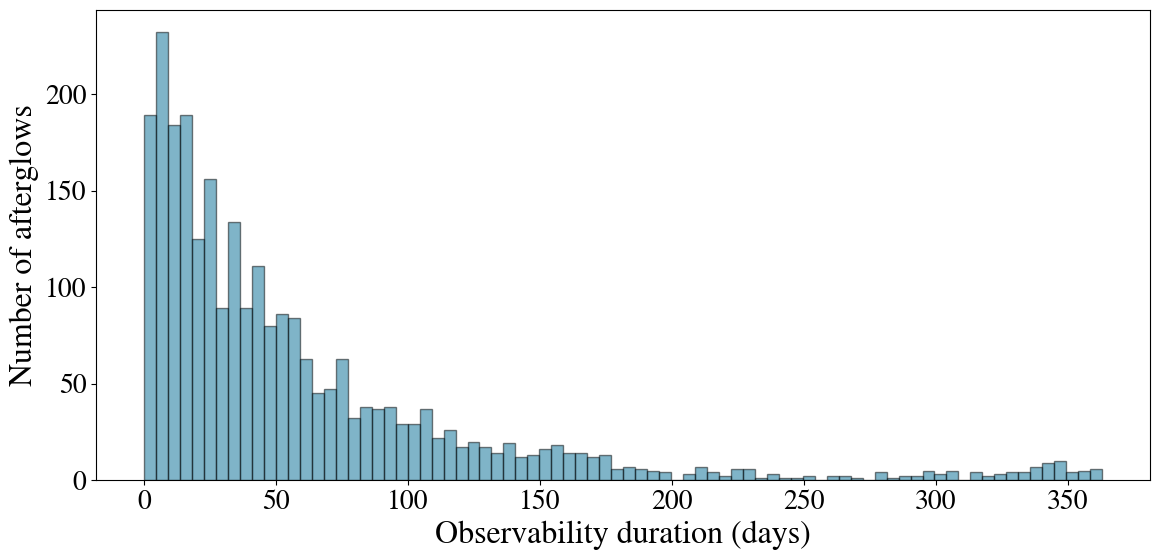

In [211]:
plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(12, 6))

plt.hist(dt, bins=80, color='#006b93', alpha=0.5, edgecolor='black')
plt.xlabel("Observability duration (days)", fontsize=23)
plt.ylabel("Number of afterglows", fontsize=23)
#plt.axvline(x=15, lw=2, color="gray", ls='--', alpha=0.6)
#plt.text(17, 80, "15 days", rotation='vertical', fontsize=20, color='gray')

plt.tight_layout()

plt.savefig("../figures/pseudo_obs_visibility_duration_distribution.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

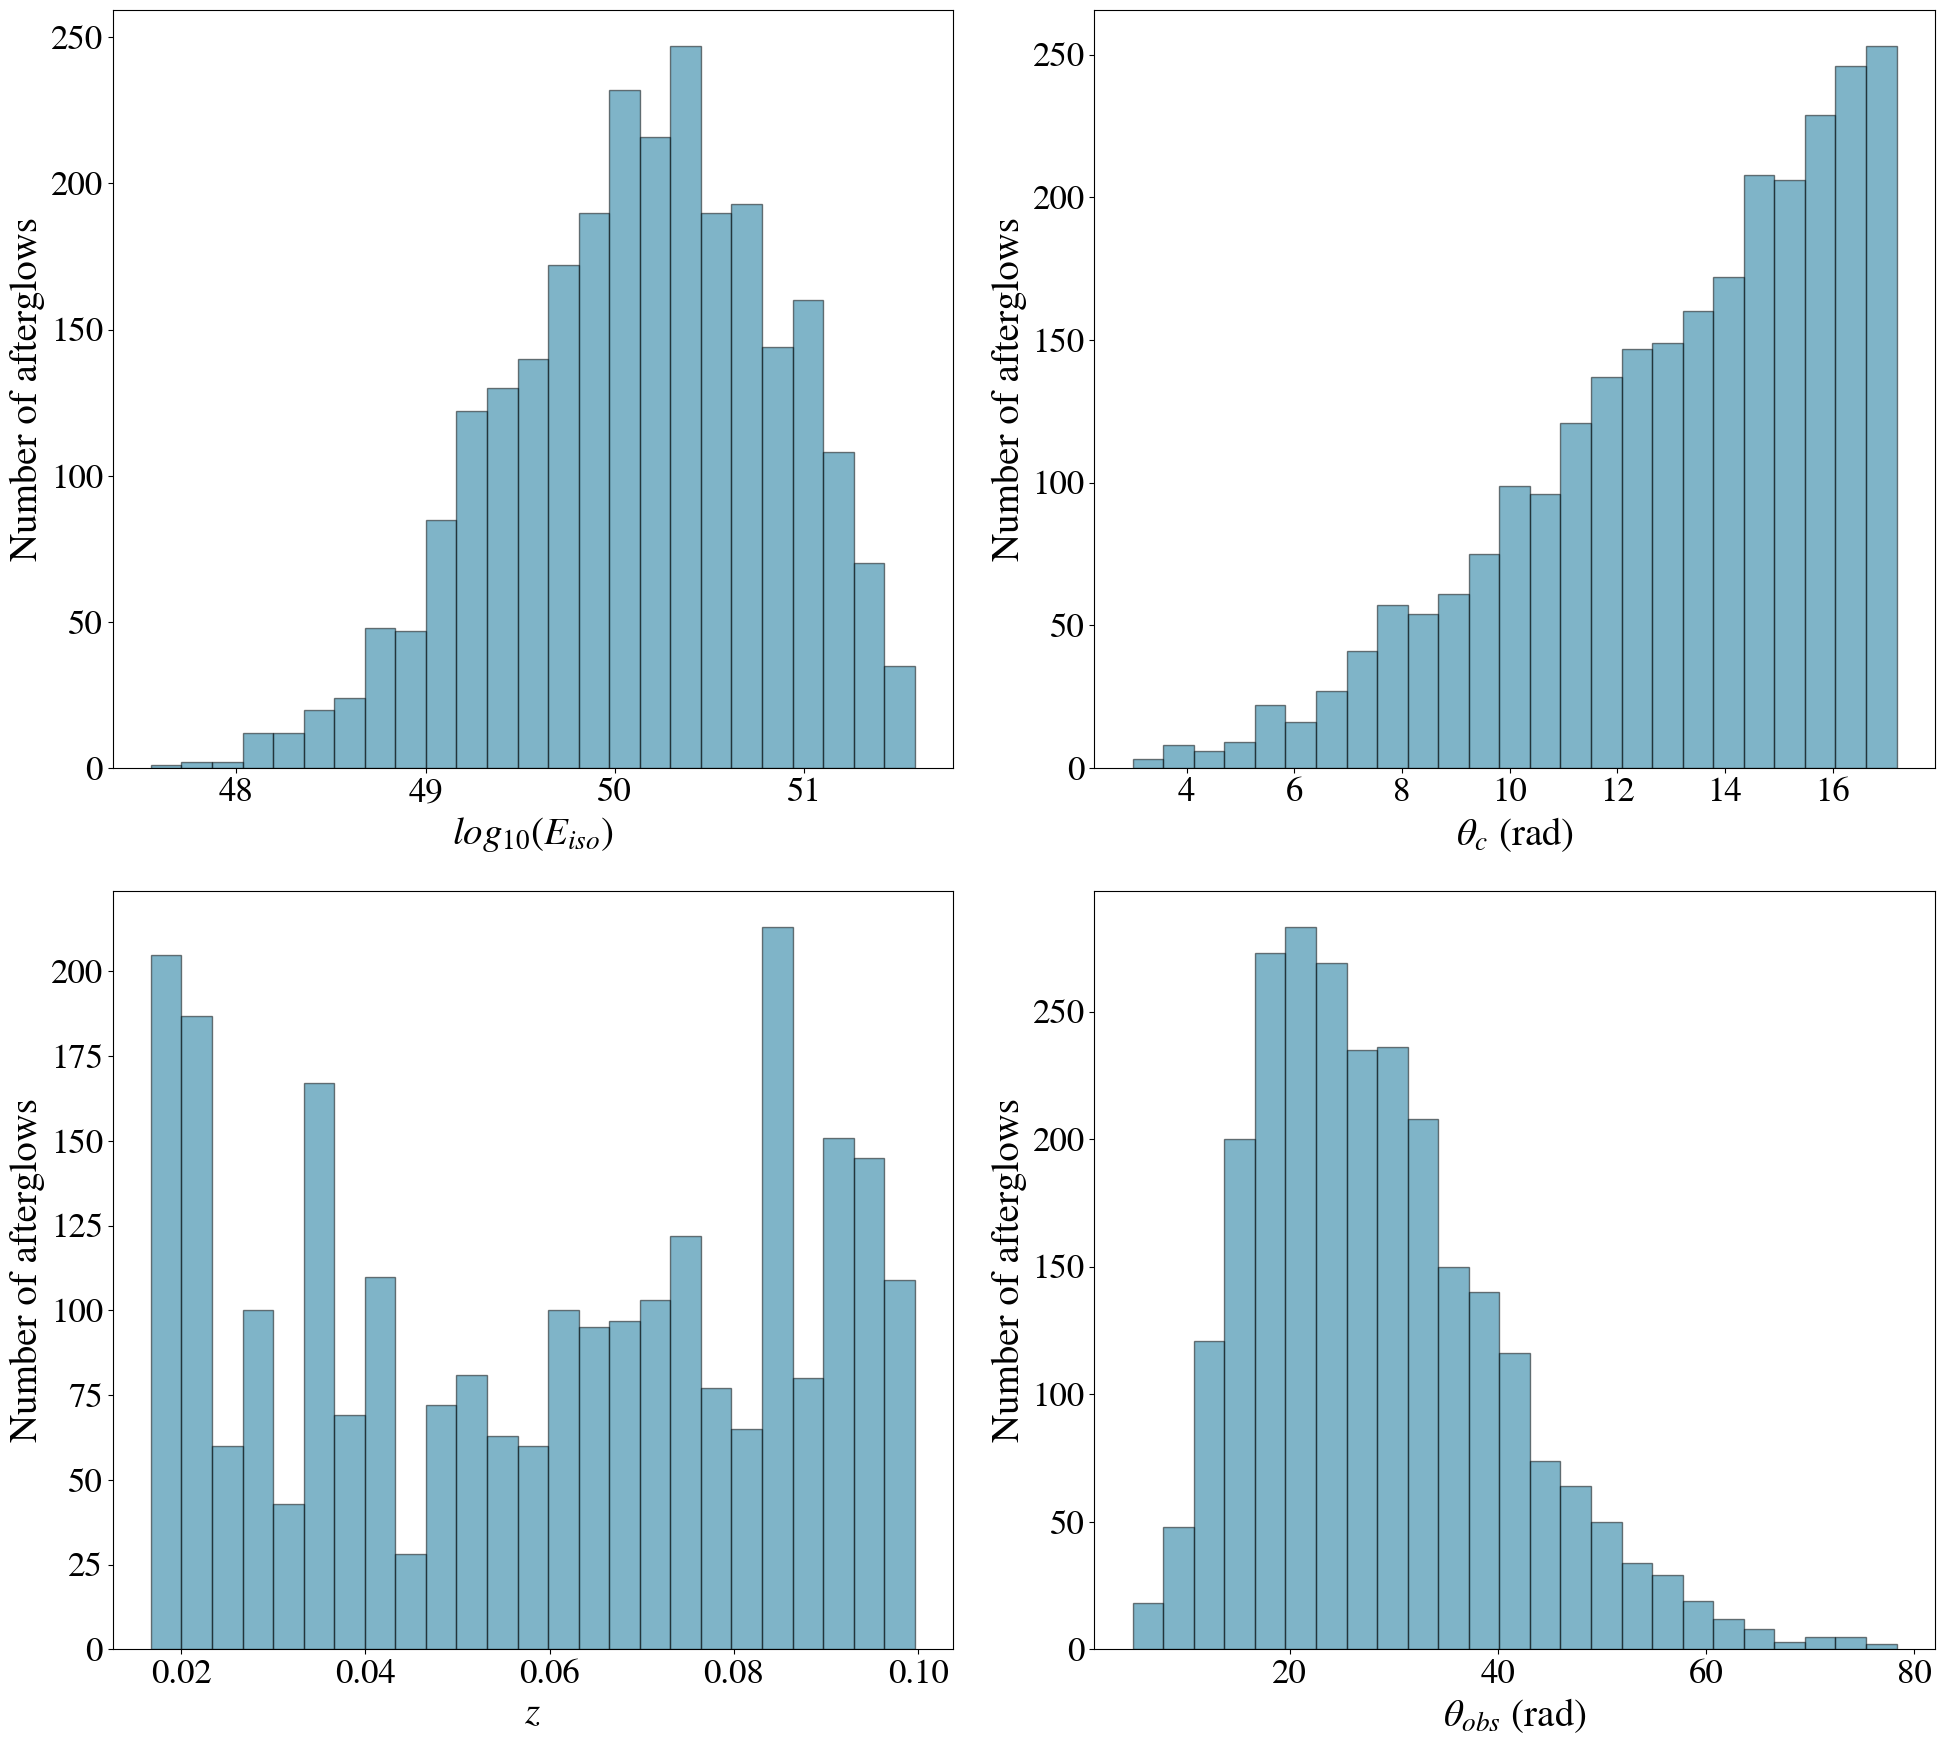

In [75]:
file_po_open = open(f'../data/orphans_pseudo_obs_5pts_low_redshift.pkl', 'rb')
po = pickle.load(file_po_open)
file_po_open.close()

df_po = pd.DataFrame(data=po)

E0_all, thetaCore_all, z_all, thetaObs_all = [], [], [], []
Eiso_all = []

for config in df_po['config']:
    E0_all.append(config['E0'])
    thetaCore_all.append(config['thetaCore'])
    z_all.append(config['z'])
    thetaObs_all.append(config['thetaObs'])
    
    Eiso_all.append(config['E0'] * (1 + (1/4) * (config['thetaObs']/config['thetaCore'])**2)**(-4/2) * 0.1)

params = [np.log10(Eiso_all), np.degrees(thetaCore_all), z_all, np.degrees(thetaObs_all)]
labels = ['$log_{10}(E_{iso})$', r'$\theta_c$ (rad)', '$z$', r'$\theta_{obs}$ (rad)']

plt.rcParams.update({'font.size': 25})
fig, axes = plt.subplots(figsize=(20,18), nrows=2, ncols=2)

for i in range(4):
    ax = axes[i//2, i%2]
    ax.hist(params[i], bins=25, label='all GRBs', edgecolor='k', color='#006b93', alpha=0.5)
    ax.set_ylabel('Number of afterglows', fontsize=28)
    ax.set_xlabel(labels[i], fontsize=28)
    #ax.legend()

plt.tight_layout() 

#plt.savefig('../figures/oa_sbat4_pop_distrib.pdf', format="pdf", bbox_inches="tight", transparent=True)
plt.show()